In [6]:
import Pkg
Pkg.activate(".")

include("./annihilation.jl")
include("./level_transition.jl")

using .ChrisWF
using CairoMakie
using Printf

  Activating project at `~/bosonSR_repo_/chris/julia_wf`


In [7]:
function sci_latex(x::Real; precision=2)
    if x == 0
        return "0"
    end
    exponent = floor(Int, log10(abs(x)))
    mantissa = x / 10.0^exponent
    return @sprintf("%.*f×10^{%d}", precision, mantissa, exponent)
end

title_fs  = 20
label_fs  = 18
tick_fs   = 16
legend_fs = 14;

# Isolated Level Transition Strain

Below is the envelope for the level transition strain. When the oscillatory term is added, it only shifts the frequency axis to the transition frequency. The width of the strain envelope is entirely set by the transition rate.

In [15]:
C = (2. ^28 * 3. ^4 * 5. ^5) / (11. ^22 * pi)

2.6569658531745073e-10


 alpha    = 0.75
 omega_tr = 3.4451407454141036e-16
 r_g(M)   = 7.4834e+12 GeV^-1
 M        = 1.1154e+51 GeV
Max N_e      ≈ 9.303e+57
Max N_g      ≈ 3.662e+58
Max h(t)     ≈ 2.148e-31
omega_tr     ≈ 3.445e-16 GeV
gamma_sre_yr ≈ 1.680e+04 1/yr
gamma_srg_yr ≈ 1.532e+04 1/yr
gamma_t_yr   ≈ 1.678e-53 1/yr
gamma_srg    ≈ 3.198e-28 1/GeV
Mu_a         ≈ 1.002e-13 GeV
Fitted centre frequency f0 = 1.873599e-04 Hz
Fitted width gamma         = 2.818588e-04 Hz
Estimated FWHM ≃ 2·gamma   = 5.637176e-04 Hz
Fitted floor C             = 5.623e-44


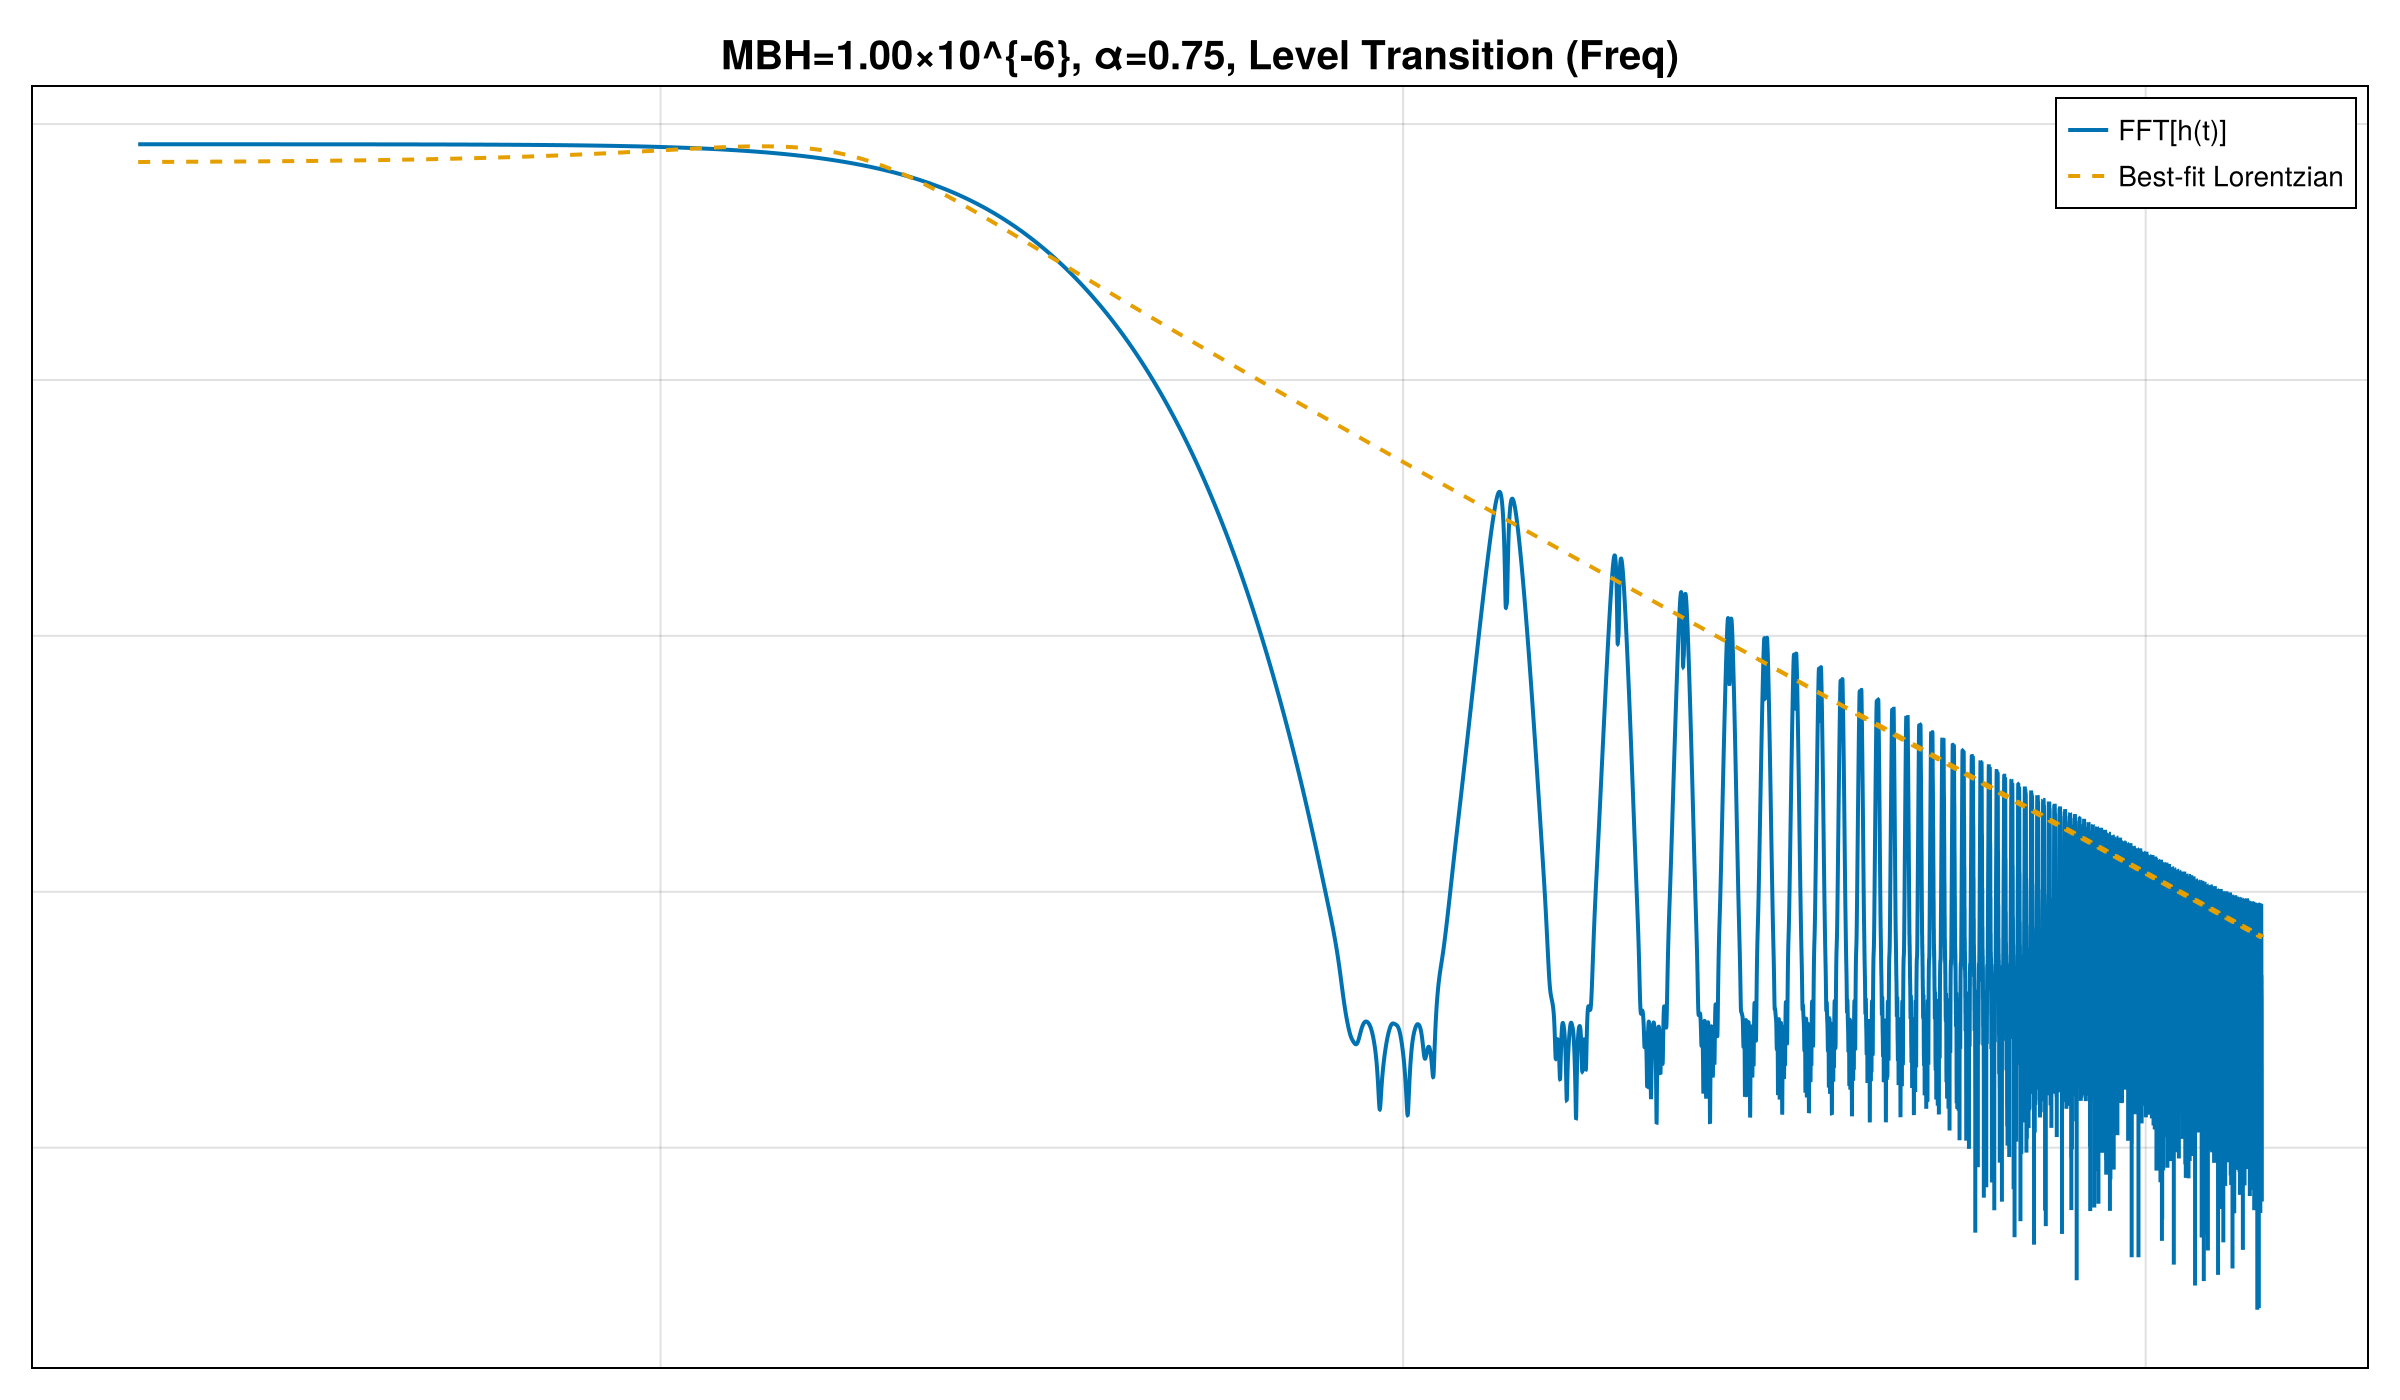

In [8]:
result = iso_gatom_level_tr_strain(
    M_solar=1e-6,
    a_spin=0.999999,
    alpha=0.75,
    ne=6,
    ng=5,
    distance_kpc=1.0,
    verbose=true,
)

f = result["f_pos"]
H = result["H_pos"]
L = result["L_full"]

A_fit, f0_fit, gamma_fit, C_fit = result["lorentz_params"]
omega_tr = result["omega_tr_GeV"]
mu_a = result["Mu_a"]
M_solar = 1e-6

fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xlabel="Frequency [Hz]",
    ylabel="|h̃(f)|",
    title="MBH=$(sci_latex(M_solar)), α=0.75, Level Transition (Freq)",
    titlesize=title_fs,
    xlabelsize=label_fs,
    ylabelsize=label_fs,
)

lines!(ax, f, abs.(H), label="FFT[h(t)]", linewidth=2)
lines!(ax, f, L, label="Best-fit Lorentzian", linewidth=2, linestyle=:dash)

axislegend(ax; fontsize=legend_fs, position=:rt)
CairoMakie.hidedecorations!(ax, grid=false)
#CairoMakie.showgrid!(ax)

fig

# Associated Time Domain Strain

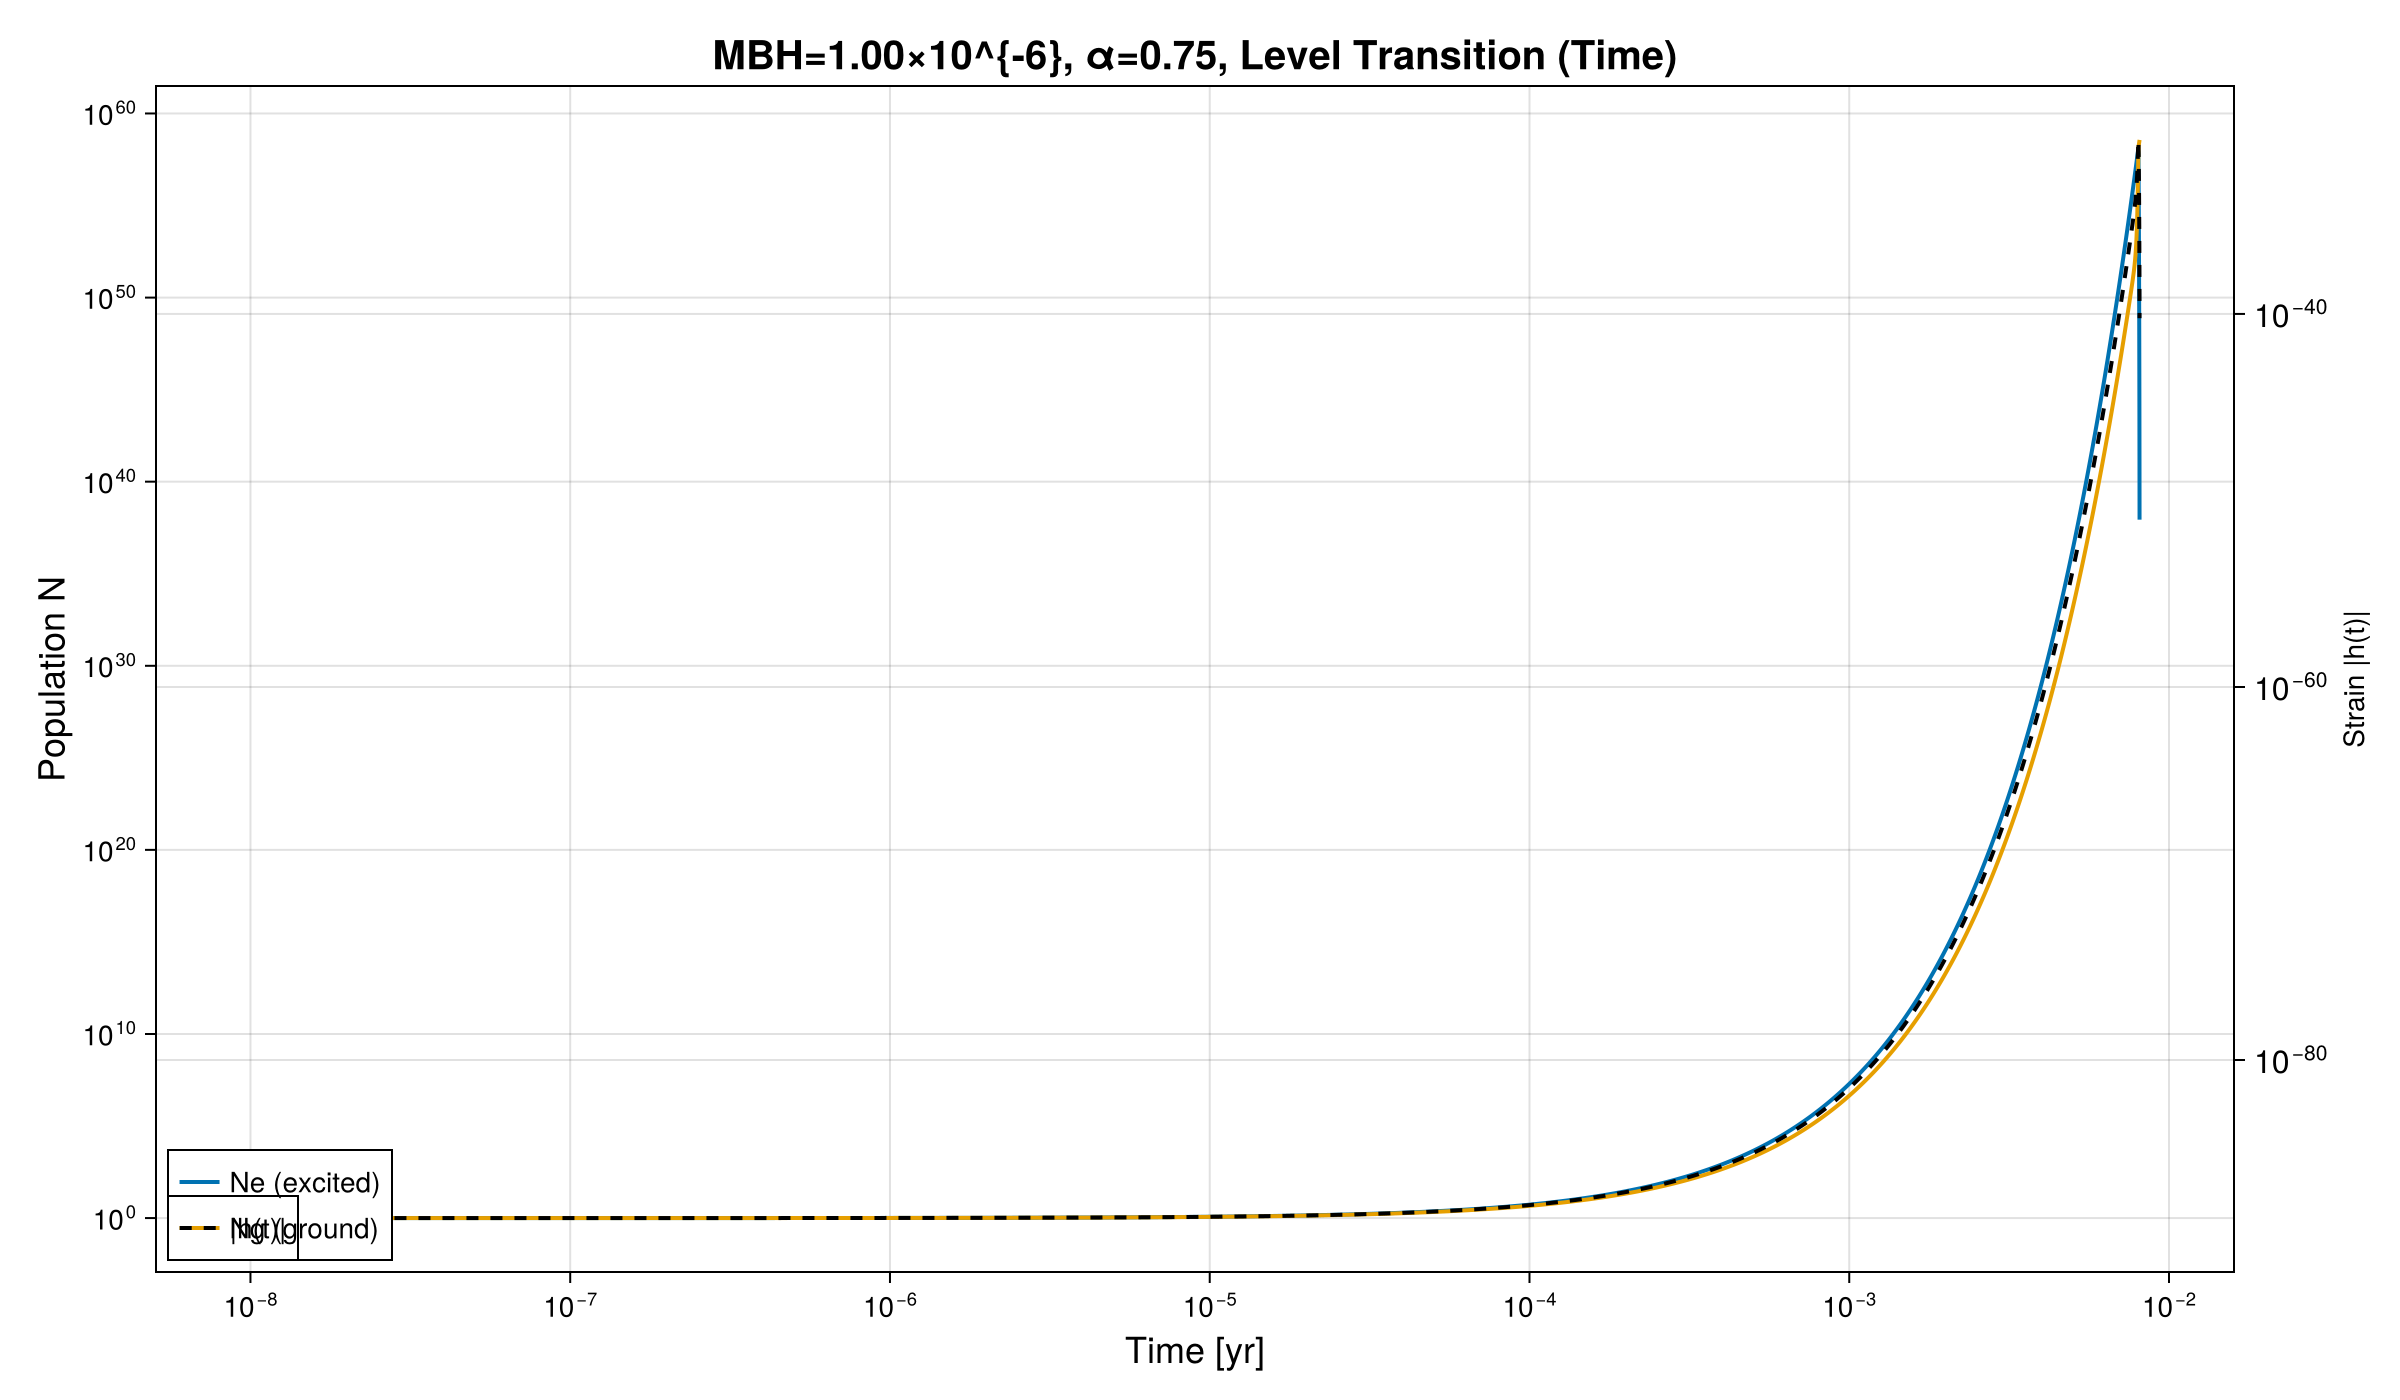

In [9]:
time_yr = result["time_yr"]
h_t = result["h_t"]
N_e = result["N_e"]
N_g = result["N_g"]

fig = Figure(size=(1200, 700))
ax1 = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xlabel="Time [yr]",
    ylabel="Population N",
    title="MBH=$(sci_latex(M_solar)), α=0.75, Level Transition (Time)",
    titlesize=title_fs,
    xlabelsize=label_fs,
    ylabelsize=label_fs,
)

lines!(ax1, time_yr, N_e, label="Ne (excited)", linewidth=2)
lines!(ax1, time_yr, N_g, label="Ng (ground)", linewidth=2)
axislegend(ax1; fontsize=legend_fs, position=:lb)

ax2 = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xlabel="Time [yr]",
    ylabel="Strain |h(t)|",
    yaxisposition=:right,
    #yticklabelposition=:right,
    yticklabelsize=tick_fs,
)
hidespines!(ax2)
hidexdecorations!(ax2)

lines!(ax2, time_yr, abs.(h_t), label="|h(t)|", linewidth=2, color=:black, linestyle=:dash)
axislegend(ax2; fontsize=legend_fs, position=:lb)

fig

# Annihilation Strain

In [10]:
M_solar_ann = 3.1e-4
mua_ann = 2e-16
distance_kpc = 1.0
n_ann = 4
iota_ann = 0.0
phase_ann = 0.0

f_min = 1e0
f_max = 1e12
N_f = 50000

res_ann = iso_gatom_ann_strain(
    M_solar=M_solar_ann,
    mua=mua_ann,
    n=n_ann,
    l=nothing,
    alpha=nothing,
    distance_kpc=distance_kpc,
    iota=iota_ann,
    phase=phase_ann,
    f_min_Hz=f_min,
    f_max_Hz=f_max,
    n_f=N_f,
    verbose=true,
)

f_Hz = res_ann["f_Hz"]
h_c = res_ann["h_c"]
h_plus = res_ann["h_plus"]
f_ann = res_ann["f_line_Hz"]
alpha_ann = res_ann["alpha"]
r_kpc = res_ann["distance_kpc"]

alpha           ≈ 4.640e-01
r_g(M)          ≈ 2.3198e+15 GeV^-1
Annihilation f_ann ≈ 9.607e+07 Hz
max |h_plus|    ≈ 8.211e-39
max h_c         ≈ 1.591e-30


1.0

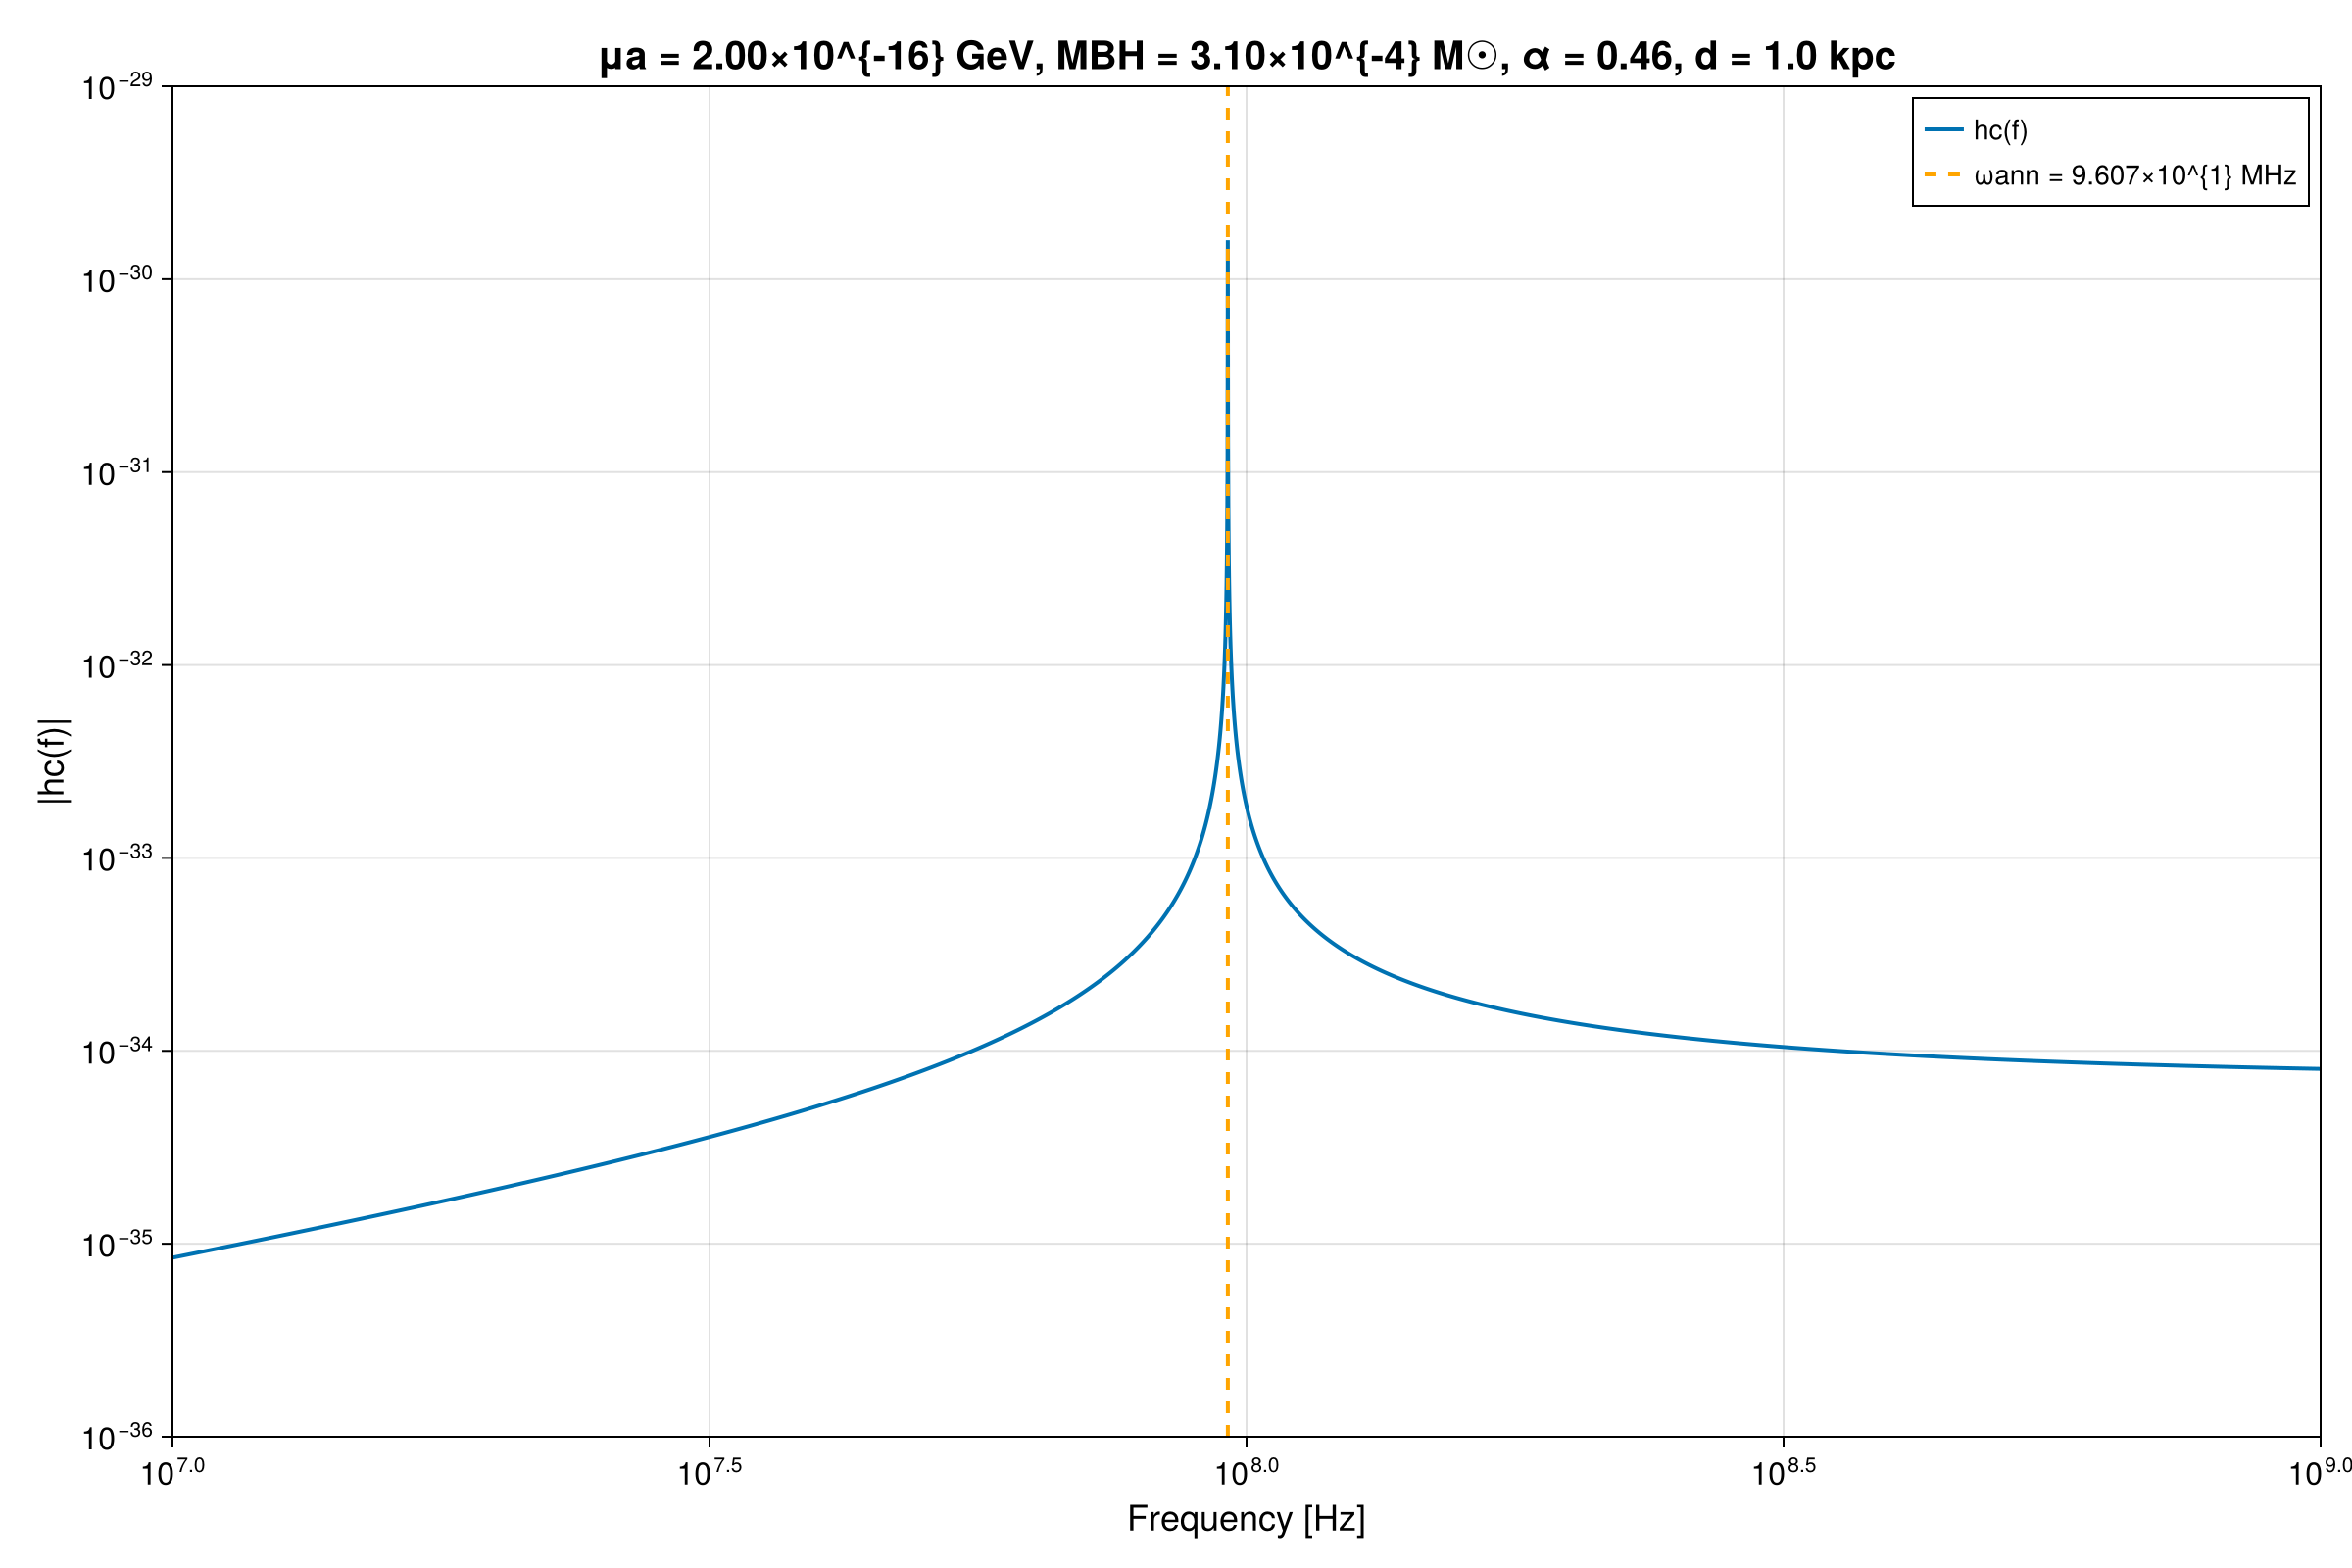

In [11]:
fig = Figure(size=(1200, 800))
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xlabel="Frequency [Hz]",
    ylabel="|hc(f)|",
    xticklabelsize=tick_fs,
    yticklabelsize=tick_fs,
    xlabelsize=label_fs,
    ylabelsize=label_fs,
)

lines!(ax, f_Hz, abs.(h_c), linewidth=2, label="hc(f)")

ax.limits = (1e7, 1e9, 1e-36, 1e-29)

vlines!(ax, f_ann; color=:orange, linestyle=:dash, linewidth=2,
    label="ωann = $(sci_latex(f_ann/1e6, precision=3)) MHz")

title_str = @sprintf("μa = %s GeV, MBH = %s M☉, α = %.2f, d = %.1f kpc",
    sci_latex(mua_ann, precision=2), sci_latex(M_solar_ann, precision=2), alpha_ann, r_kpc)
ax.title = title_str
ax.titlesize = title_fs

axislegend(ax; fontsize=legend_fs)

fig

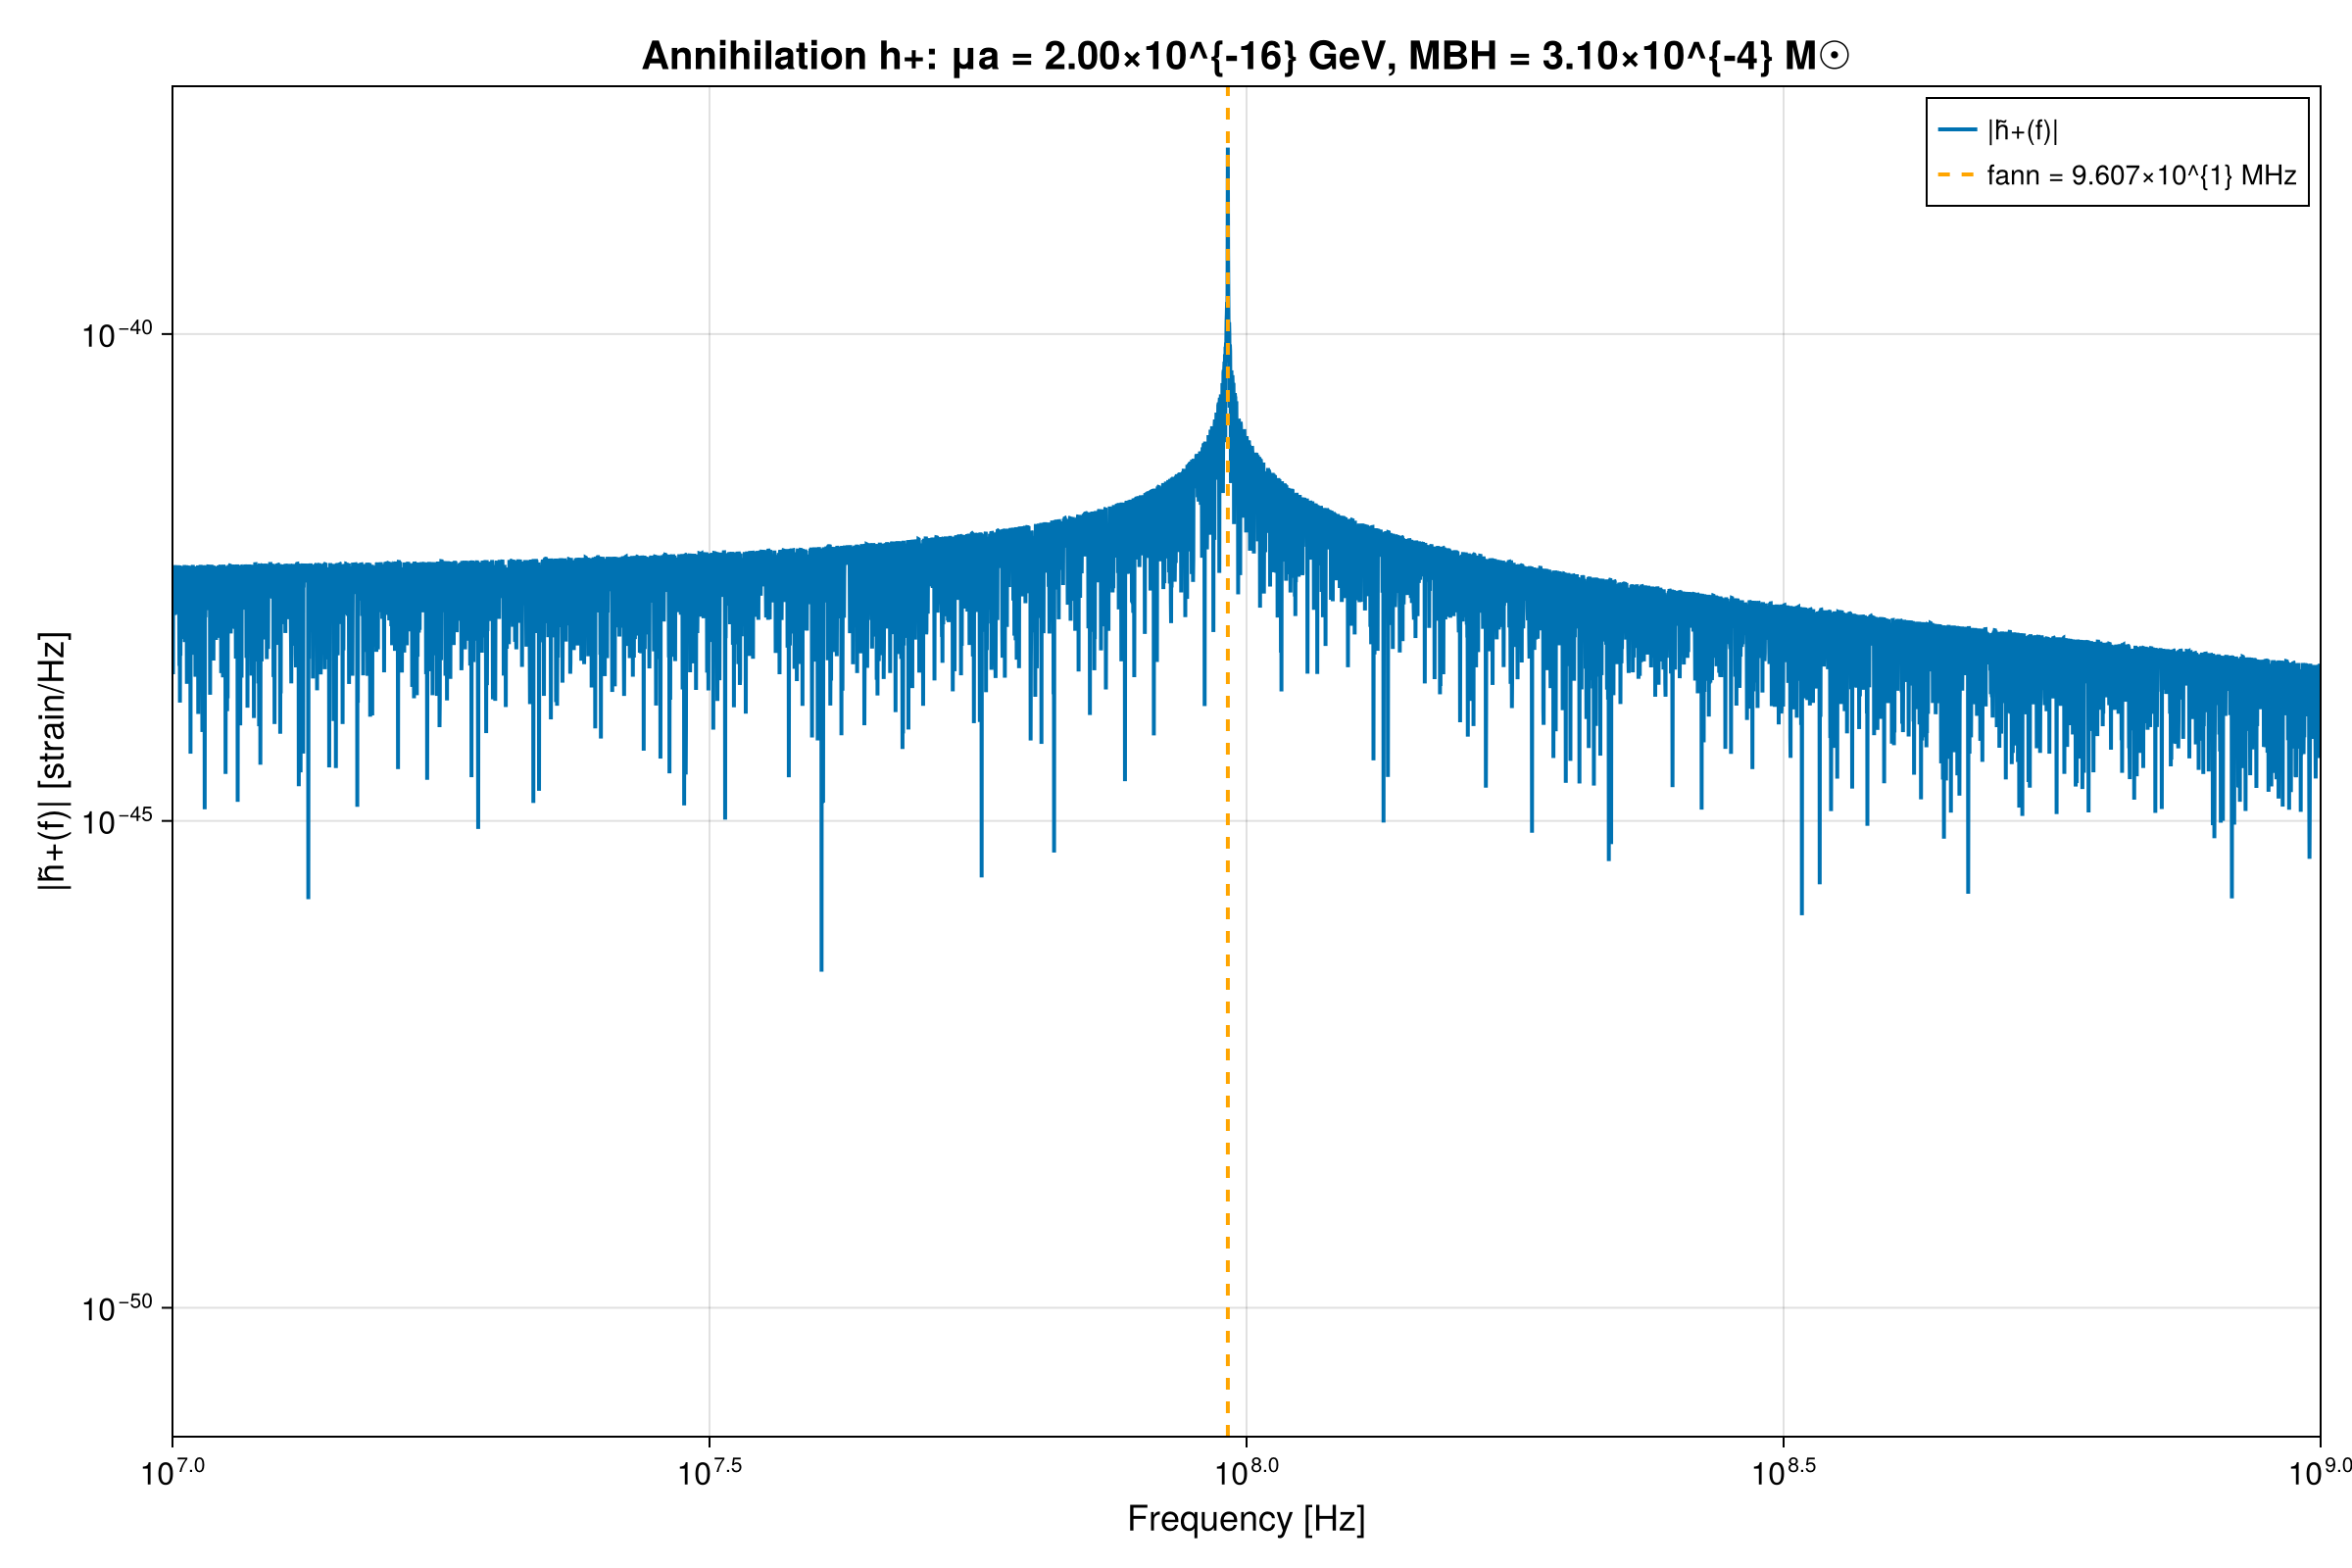

In [12]:
fig = Figure(size=(1200, 800))
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xlabel="Frequency [Hz]",
    ylabel="|h̃+(f)| [strain/Hz]",
    xticklabelsize=tick_fs,
    yticklabelsize=tick_fs,
    xlabelsize=label_fs,
    ylabelsize=label_fs,
)

lines!(ax, f_Hz, abs.(h_plus), linewidth=2, label="|h̃+(f)|")

ax.limits = (1e7, 1e9, nothing, nothing)

vlines!(ax, f_ann; color=:orange, linestyle=:dash, linewidth=2,
    label="fann = $(sci_latex(f_ann/1e6, precision=3)) MHz")

title_str = @sprintf("Annihilation h+: μa = %s GeV, MBH = %s M☉",
    sci_latex(mua_ann, precision=2), sci_latex(M_solar_ann, precision=2))
ax.title = title_str
ax.titlesize = title_fs

axislegend(ax; fontsize=legend_fs)

fig

# Both Strains on the Same Axis

Overlay the Lorentzian-fitted level-transition strain and the annihilation characteristic strain. Note that the level transition is essentially a delta spike for the detectors we are considering; the duration is far too short to realistically detect for most masses considered.

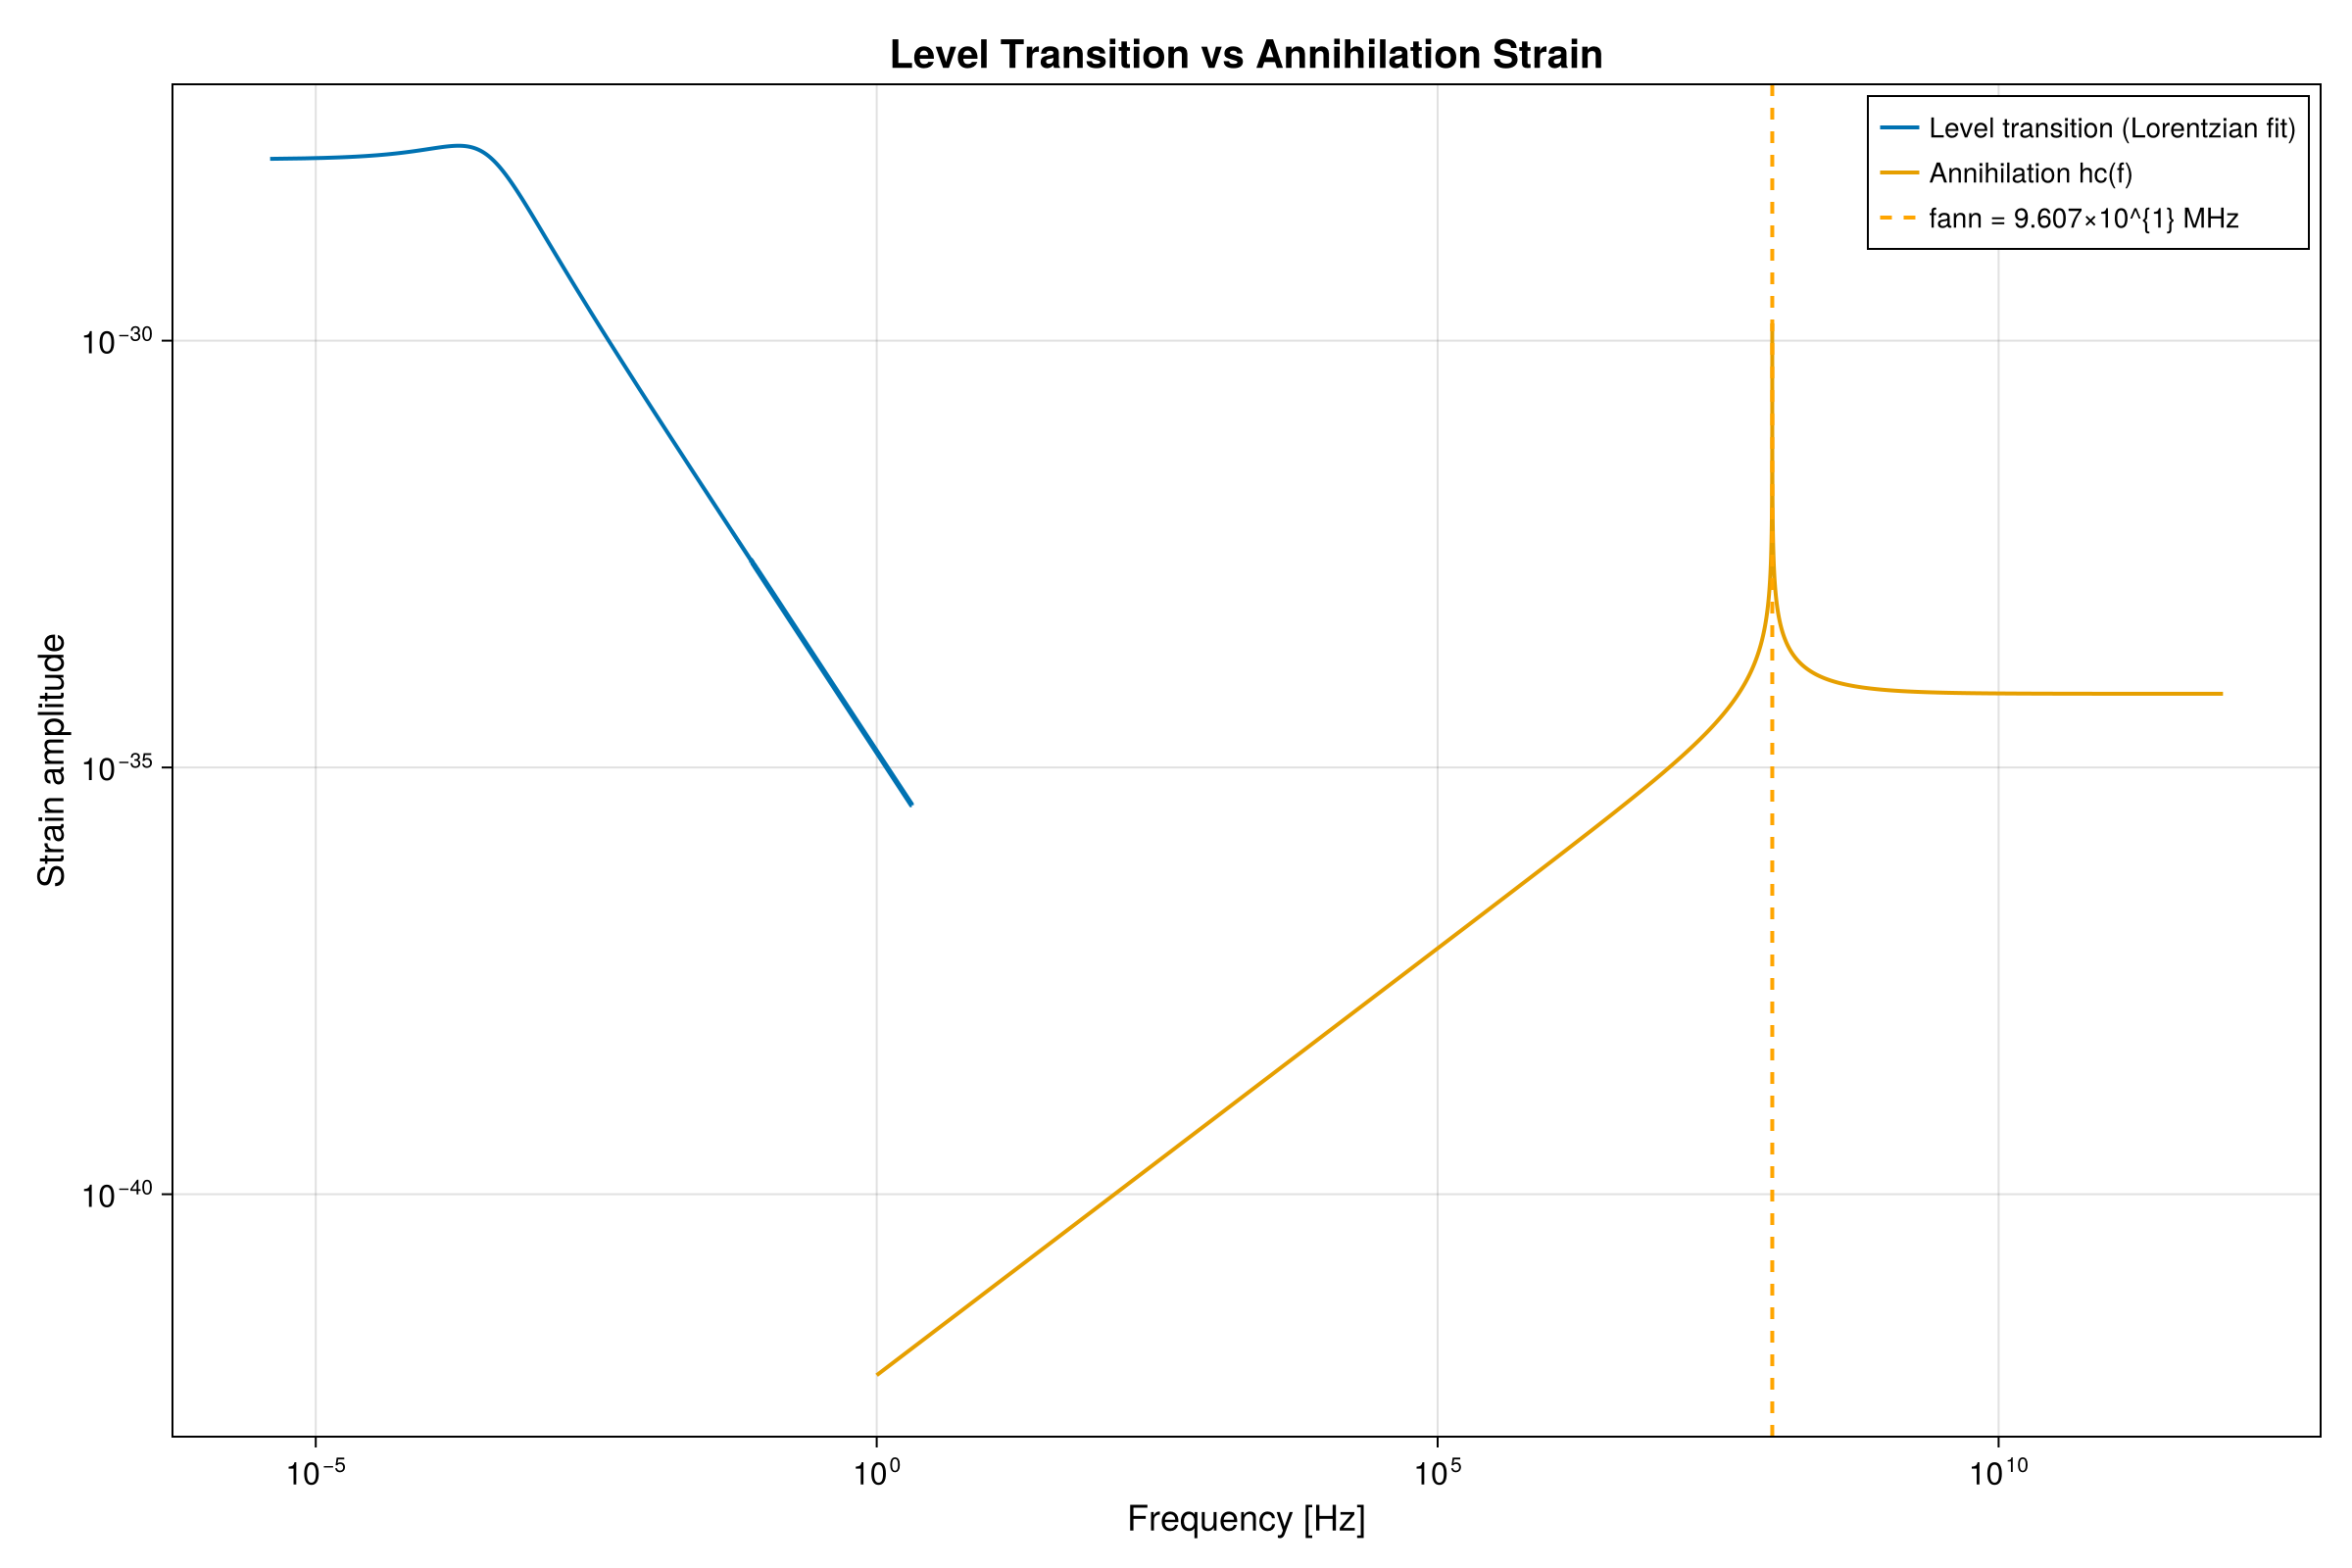

In [14]:
fig = Figure(size=(1200, 800))
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xlabel="Frequency [Hz]",
    ylabel="Strain amplitude",
    xticklabelsize=tick_fs,
    yticklabelsize=tick_fs,
    xlabelsize=label_fs,
    ylabelsize=label_fs,
)

lines!(ax, f, L, linewidth=2, label="Level transition (Lorentzian fit)")
lines!(ax, f_Hz, abs.(h_c), linewidth=2, label="Annihilation hc(f)")

vlines!(ax, f_ann; color=:orange, linestyle=:dash, linewidth=2,
    label="fann = $(sci_latex(f_ann/1e6, precision=3)) MHz")

ax.title = "Level Transition vs Annihilation Strain"
ax.titlesize = title_fs

axislegend(ax; fontsize=legend_fs)

fig